<a href="https://colab.research.google.com/github/Sam-Gyu/naive-bayes-from-scratch/blob/main/Naive_Bayes_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Gaussian Naive Bayes vs. Multinomial Naive Bayes

---

**Course:** Cognitive  
**Objective:** Implement two Naive Bayes classifiers from scratch without using ML classifier libraries.

---

## Table of Contents
1. [Imports & Setup](#imports)
2. [Part 1 – Utility Functions](#part1)
3. [Part 2 – Gaussian Naive Bayes (Abalone Dataset)](#part2)
4. [Part 3 – Multinomial Naive Bayes (IMDB Dataset)](#part3)
5. [Part 4 – Log Probability Comparison](#part4)
6. [Part 5 – Visualizations](#part5)

---
## Imports & Setup <a id='imports'></a>

In [22]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import os
import re
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import pickle
import urllib.request

---
## Part 1 – Utility Functions <a id='part1'></a>

Implementing the following helper functions **from scratch** (without `numpy.mean()`, `numpy.var()`, or `sklearn.metrics.accuracy_score`):

| Function | Formula |
|---|---|
| `compute_mean` | $ \mu = \frac{1}{n} \sum x_i $ |
| `compute_variance` | $ \sigma^2 = \frac{1}{n} \sum (x_i - \mu)^2 $ |
| `compute_accuracy` | $ \text{Accuracy} = \frac{\text{correct predictions}}{\text{total samples}} $ |

In [23]:
def compute_mean(values):
    """Formula: μ = (1/n) * Σ xi"""
    if len(values) == 0:
        return 0
    return sum(values) / len(values)


def compute_variance(values):
    """Formula: σ2 = (1/n) * Σ (xi - μ)2"""
    if len(values) == 0:
        return 0
    mu = compute_mean(values)
    return sum((x - mu) ** 2 for x in values) / len(values)


def compute_accuracy(y_true, y_pred):
    """Formula: Accuracy = correct_predictions / total_samples"""
    if len(y_true) == 0:
        return 0
    correct = sum(1 for yt, yp in zip(y_true, y_pred) if yt == yp)
    return correct / len(y_true)

---
## Part 2 – Gaussian Naive Bayes <a id='part2'></a>

**Dataset:** [Abalone Dataset (Kaggle)](https://www.kaggle.com/datasets/rodolfomendes/abalone-dataset)  
**Task:** Predict age group from shell measurements.

| Rings | Class |
|---|---|
| ≤ 8 | Young |
| 9–11 | Adult |
| ≥ 12 | Old |

### 2.1 – Load & Preprocess Dataset

In [24]:
def load_abalone_data(path):
    # Check if file exists, if not, download it
    if not os.path.exists(path):
        print(f"File {path} not found. Downloading from UCI repository...")
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
        urllib.request.urlretrieve(url, path)
        print(f"Downloaded {path}")

    # Column names from abalone.names
    columns = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
               'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
    df = pd.read_csv(path, names=columns)

    # Convert Rings → (Young, Adult, Old)
    def categorize_rings(rings):
        if rings <= 8:
            return 'Young'
        elif rings <= 11:  # 9-11 inclusive
            return 'Adult'
        else:
            return 'Old'

    df['Age_Group'] = df['Rings'].apply(categorize_rings)

    # Select only the numeric features (excluding Sex and Rings)
    feature_columns = ['Length', 'Diameter', 'Height', 'Whole_weight',
                       'Shucked_weight', 'Viscera_weight', 'Shell_weight']
    X = df[feature_columns].values
    y = df['Age_Group'].values

    return X, y, df

### 2.2 – Train / Test Split (80 / 20)

In [25]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    np.random.seed(random_state)
    indices = np.arange(len(X))
    np.random.shuffle(indices)

    test_samples = int(len(X) * test_size)
    test_idx = indices[:test_samples]
    train_idx = indices[test_samples:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

### 2.3 – Gaussian Naive Bayes Classifier

`GaussianNaiveBayes(use_log=False)` (default) multiplies Gaussian PDFs in linear space; `use_log=True` scores entirely in log space (see section 4.1). Public `predict_prob(sample)` returns a dict of class → normalized probability, matching a Gaussian-style API with explicit per-class posteriors.

In [26]:
class GaussianNaiveBayes:
    def __init__(self, use_log=False):
        self.use_log = use_log
        self.classes = None
        self.priors = {}
        self.means = {}
        self.variances = {}

    def fit(self, X_train, y_train):
        self.classes = sorted(set(y_train))
        num_samples = len(X_train)

        for c in self.classes:
            mask = (y_train == c)
            X_class = X_train[mask]
            self.priors[c] = len(X_class) / num_samples

            n_features = X_train.shape[1]
            class_means = []
            class_variances = []

            for feature_indx in range(n_features):
                feature_values = X_class[:, feature_indx]
                class_means.append(compute_mean(feature_values))
                class_variances.append(compute_variance(feature_values))

            self.means[c] = class_means
            self.variances[c] = class_variances

    def gaussian_pdf(self, x, mean, var):
        eps = 1e-9
        coeff = 1.0 / math.sqrt(2 * math.pi * (var + eps))
        exponent = math.exp(-((x - mean) ** 2) / (2 * (var + eps)))
        return coeff * exponent

    def log_gaussian_pdf(self, x, mean, var):
        eps = 1e-9
        log_coeff = -0.5 * math.log(2 * math.pi * (var + eps))
        log_exp = -((x - mean) ** 2) / (2 * (var + eps))
        return log_coeff + log_exp

    def predict_prob(self, sample):
        """Posterior over classes: linear PDF product, or full log-sum-exp when use_log is True."""
        x = np.asarray(sample, dtype=float).reshape(-1)
        if self.use_log:
            logp = {}
            for c in self.classes:
                lp = math.log(self.priors[c] + 1e-300)
                for j, xj in enumerate(x):
                    lp += self.log_gaussian_pdf(float(xj), self.means[c][j], self.variances[c][j])
                logp[c] = lp
            m = max(logp.values())
            raw = {c: math.exp(logp[c] - m) for c in self.classes}
            total = sum(raw.values())
            return {c: raw[c] / total for c in self.classes}
        raw = {}
        for c in self.classes:
            p = self.priors[c]
            for j, xj in enumerate(x):
                p *= self.gaussian_pdf(float(xj), self.means[c][j], self.variances[c][j])
            raw[c] = p
        total = sum(raw.values())
        if total <= 0 or not math.isfinite(total):
            logp = {}
            for c in self.classes:
                lp = math.log(self.priors[c] + 1e-300)
                for j, xj in enumerate(x):
                    lp += self.log_gaussian_pdf(float(xj), self.means[c][j], self.variances[c][j])
                logp[c] = lp
            m = max(logp.values())
            raw = {c: math.exp(logp[c] - m) for c in self.classes}
            total = sum(raw.values())
        return {c: raw[c] / total for c in self.classes}

    def predict(self, sample):
        probs = self.predict_prob(sample)
        return max(probs, key=probs.get)


### 2.4 – Train & Evaluate (without log)

In [27]:

X, y, df_full = load_abalone_data('abalone.data')
X_train, X_test, y_train, y_test = train_test_split_manual(X, y)

model = GaussianNaiveBayes()
model.fit(X_train, y_train)

for c in model.classes:
    print(f"\n{c}: prior = {model.priors[c]:.4f}")
    print(f"  Length \u2192 mean={model.means[c][0]:.4f}, var={model.variances[c][0]:.4f}")


Adult: prior = 0.4297
  Length → mean=0.5716, var=0.0076

Old: prior = 0.2325
  Length → mean=0.5868, var=0.0066

Young: prior = 0.3378
  Length → mean=0.4229, var=0.0120


### 2.5 – Single Sample: `predict` and `predict_prob`

In [28]:
# Test-set predictions (Gaussian PDF likelihood × class prior)
y_pred_gaussian = np.array([model.predict(X_test[i]) for i in range(len(X_test))])
gaussian_accuracy = compute_accuracy(list(y_test), list(y_pred_gaussian))
print(f"Gaussian NB test accuracy: {gaussian_accuracy:.4f}")

# Single sample: class probabilities and predicted label
sample = X_test[0]
print(f"\nFirst test sample (features): {sample}")
print(f"True label: {y_test[0]}")
print("predict_prob(sample):")
for cls_name, p in model.predict_prob(sample).items():
    print(f"  {cls_name}: {p:.4f}")
print(f"predict(sample): {model.predict(sample)}")


Gaussian NB test accuracy: 0.5653

First test sample (features): [0.605  0.455  0.16   1.1035 0.421  0.3015 0.325 ]
True label: Adult
predict_prob(sample):
  Adult: 0.5985
  Old: 0.4015
  Young: 0.0000
predict(sample): Adult


### 2.6 – Dummy Sample

In [29]:
def example_usage():
    # Load the dataset
    X, y, df_full = load_abalone_data('abalone.data')
    print("Abalone data loaded and Rings converted to Age_Group.")
    print(f"Dataset shape: {X.shape}")
    print(f"Feature columns: Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight")

    # Show class distribution
    class_counts = pd.Series(y).value_counts()
    print(f"\nClass distribution:")
    for age_group, count in class_counts.items():
        print(f"  {age_group}: {count} samples ({count/len(y)*100:.1f}%)")

    # Perform train/test split
    X_train, X_test, y_train, y_test = train_test_split_manual(X, y)
    print(f"\nData split into training ({len(X_train)} samples) and testing ({len(X_test)} samples).")

    # Example of using compute_mean and compute_variance
    sample_values = [1, 2, 3, 4, 5]
    mean_val = compute_mean(sample_values)
    variance_val = compute_variance(sample_values)
    print(f"\nSample values: {sample_values}")
    print(f"Computed Mean: {mean_val}")
    print(f"Computed Variance: {variance_val}")

    # Example of using compute_accuracy (dummy prediction)
    dummy_y_pred = y_test.copy()
    # Introduce some errors for demonstration
    if len(dummy_y_pred) > 0:
        dummy_y_pred[0] = 'Wrong'
    if len(dummy_y_pred) > 1:
        dummy_y_pred[1] = 'Also Wrong'

    accuracy_val = compute_accuracy(y_test, dummy_y_pred)
    print(f"\nDummy Accuracy: {accuracy_val:.4f}")


    # Show feature statistics per class (helpful for Ahmed's part)
    print("\n" + "="*60)
    print("Feature Statistics per Class (for Ahmed's Gaussian NB):")
    print("="*60)

    # Create a dataframe with training features and labels for easy grouping
    X_train_df = pd.DataFrame(X_train, columns=['Length', 'Diameter', 'Height', 'Whole_weight',
                                                 'Shucked_weight', 'Viscera_weight', 'Shell_weight'])
    X_train_df['Age_Group'] = y_train

    for age_group in ['Young', 'Adult', 'Old']:
        subset = X_train_df[X_train_df['Age_Group'] == age_group]
        print(f"\n{age_group} Class (n={len(subset)}):")
        for feature in ['Length', 'Diameter', 'Height', 'Whole_weight',
                       'Shucked_weight', 'Viscera_weight', 'Shell_weight']:
            mean_val = compute_mean(subset[feature].values)
            var_val = compute_variance(subset[feature].values)
            print(f"  {feature}: mean={mean_val:.4f}, variance={var_val:.4f}")

    # Verify the split and data integrity
    print("\n" + "="*60)
    print("Data Verification:")
    print("="*60)
    print(f"Training set - X shape: {X_train.shape}, y shape: {y_train.shape}")
    print(f"Test set - X shape: {X_test.shape}, y shape: {y_test.shape}")
    print(f"\nSample from training set (first 3 samples):")
    for i in range(min(3, len(X_train))):
        print(f"  Sample {i+1}: {X_train[i]}")
        print(f"  Label: {y_train[i]}")


In [30]:
# example_usage()

---
## Part 3 – Multinomial Naive Bayes <a id='part3'></a>

**Dataset:** [IMDB Large Movie Review Dataset](https://ai.stanford.edu/~amaas/data/sentiment/)  
**Task:** Binary sentiment classification (positive / negative)  
**Size:** 50,000 reviews (25k train / 25k test)

### 3.1 – Load IMDB Dataset

In [31]:
def load_data(data_dir):

    texts = []
    labels = []

    for sentiment in ['pos', 'neg']:
        folder = os.path.join(data_dir, sentiment)

        for file in os.listdir(folder):
            with open(os.path.join(folder, file), 'r', encoding='utf-8') as f:
                texts.append(f.read())
                labels.append(1 if sentiment == 'pos' else 0)

    df = pd.DataFrame({
        "text": texts,
        "target": labels
    })

    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    return df

### 3.2 – Build Vocabulary

In [32]:
def vocabulary(text):
    vocab = {}
    index = 0

    for txt in text:
        words = txt.lower().split()
        for word in words:
            if word not in vocab:
                vocab[word] = index
                index += 1

    return vocab

### 3.3 – Bag-of-Words Representation

In [33]:
def vectorize_text(text_data, vocab=None):
    if vocab is None:
        vocab = vocabulary(text_data)
    features = bag_of_word(text_data, vocab)
    return features, vocab

def bag_of_word(text, vocab):
    bow_vectors = []

    for txt in text:
        # initialize vector with zeros
        vector = [0] * len(vocab)

        words = txt.lower().split()

        for word in words:
            if word in vocab:
                index = vocab[word]
                vector[index] += 1

        bow_vectors.append(vector)

    return bow_vectors

### 3.2 – Text Preprocessing

In [34]:
def initialize_nltk():
    resources = ['stopwords', 'punkt', 'punkt_tab']
    for resource in resources:
        nltk.download(resource, quiet=True)


initialize_nltk()

ps = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))
if 'not' in STOPWORDS:
    STOPWORDS.remove('not')

In [35]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = "".join([char.lower() for char in text if char not in string.punctuation])
    tokens = word_tokenize(text)
    cleaned_tokens = [ps.stem(word) for word in tokens if word not in STOPWORDS]
    return " ".join(cleaned_tokens)


def clean_df(df, column_name='cleaned_text', verbose=False):
    initial_count = len(df)
    df = df.dropna(subset=[column_name])
    df = df[df[column_name].str.strip() != ""]
    df = df.drop_duplicates(subset=[column_name])
    if verbose:
        final_count = len(df)
        print(f"Removed {initial_count - final_count} rows")
    return df


def processed_data(path, sample_size=None, cache_path=None, vocab=None):
    if cache_path and os.path.exists(cache_path):
        print(f"--- Loading cached data from {cache_path} ---")
        with open(cache_path, 'rb') as f:
            return pickle.load(f)

    print(f"--- Loading Data from {path} ---")
    df = load_data(path)
    print(f"Initial shape: {df.shape}")

    if sample_size:
        print(f"--- Using sample of {sample_size} ---")
        df = df.head(sample_size).copy()
        print(f"Shape after sampling: {df.shape}")

    print("--- Cleaning Data ---")
    df['cleaned_text'] = df['text'].apply(clean_text)
    df = clean_df(df, verbose=True)
    print(f"Shape after cleaning: {df.shape}")

    print("--- Vectorizing Data ---")
    features, vocab = vectorize_text(df['cleaned_text'], vocab=vocab)

    features = np.array(features, dtype=np.int32)
    features_df = pd.DataFrame(features, columns=list(vocab.keys()))

    target = df['target'].values

    result = (features_df, target, vocab)

    if cache_path:
        print(f"--- Saving processed data to {cache_path} ---")
        os.makedirs(os.path.dirname(cache_path), exist_ok=True)
        with open(cache_path, 'wb') as f:
            pickle.dump(result, f)

    return result


### 3.5 – Multinomial Naive Bayes Classifier

In [36]:
class MultinomialNB:
  def __init__(self, alpha = 1, use_log = False):
    self.alpha = alpha
    self.use_log = use_log

  def counts_based_onclass(self, x, y):
    self.n_features = x.shape[1]
    self.count_matrix = []

    for j in range(self.n_classes):
        mask = y[:, j].astype(bool)
        class_counts = np.asarray(x[mask].sum(axis=0)).flatten()
        self.count_matrix.append(class_counts)

    self.class_count = y.sum(axis=0)


  def compute_priors(self):
    num = self.class_count
    total = self.class_count.sum()

    return num / total

  def compute_log_priors(self):
    num = self.class_count
    total = self.class_count.sum()

    return np.log(num) - np.log(total)

  def compute_likelihood(self):
    matrix = np.array(self.count_matrix)
    num = matrix + self.alpha
    total = num.sum(axis=1).reshape(-1, 1)
    return num / total

  def compute_log_likelihood(self):
    matrix = np.array(self.count_matrix)
    num = matrix + self.alpha
    total = num.sum(axis=1).reshape(-1, 1)
    return np.log(num) - np.log(total)

  def fit(self, X, y):
    if hasattr(X, 'sparse'):
        X = X.sparse.to_coo().tocsr()

    self.classes = np.unique(y)
    self.n_classes = len(self.classes)

    y_onehot = np.zeros((len(y), self.n_classes))
    for i, c in enumerate(self.classes):
      y_onehot[:, i] = (y == c)

    self.counts_based_onclass(X, y_onehot)
    if self.use_log:
      self.priors = self.compute_log_priors()
      self.likelihoods = self.compute_log_likelihood()
    else:
      self.priors = self.compute_priors()
      self.likelihoods = self.compute_likelihood()

  def _feature_counts(self, point):
    if hasattr(point, "values") and not isinstance(point, np.ndarray):
      arr = np.asarray(point.values, dtype=float)
    else:
      arr = np.asarray(point, dtype=float)
    return arr.reshape(-1)

  def predict_prob(self, point):
    """Normalized P(class | doc) for BoW counts; keys are class labels (same as GaussianNB.predict_prob)."""
    arr = self._feature_counts(point)
    log_scores = np.zeros(self.n_classes)
    for k in range(self.n_classes):
      if self.use_log:
        s = float(self.priors[k])
        for i in range(self.n_features):
          c = int(arr[i])
          if c:
            s += float(self.likelihoods[k, i]) * c
      else:
        s = math.log(float(self.priors[k]) + 1e-300)
        for i in range(self.n_features):
          c = int(arr[i])
          if c:
            s += c * math.log(float(self.likelihoods[k, i]) + 1e-300)
      log_scores[k] = s
    m = float(np.max(log_scores))
    exp_s = np.exp(log_scores - m)
    tot = float(np.sum(exp_s))
    probs = exp_s / tot
    return {self.classes[k]: float(probs[k]) for k in range(self.n_classes)}

  def predict_all(self, X_test):
    if hasattr(X_test, 'sparse'):
        X_test = X_test.sparse.to_coo().tocsr()

    def get_row(i):
        row = X_test.iloc[i]
        if hasattr(row, 'todense'):
            return np.asarray(row.todense()).flatten()
        return row.values

    return np.array([self.predict(get_row(i))
                    for i in range(X_test.shape[0])])

  def predict(self, point):
    probs = self.priors.copy()
    for i in range(self.n_features):
        cat = int(point[i])
        if self.use_log:
          probs += self.likelihoods[:, i] * cat
        else:
            probs *= self.likelihoods[:, i] ** cat
    return self.classes[np.argmax(probs)]

### 3.6 – Train & Evaluate

In [37]:
def data_saver(train_path, test_path, train_cache, test_cache):
    X_train, y_train, vocab = processed_data(
        train_path,
        sample_size=10000,
        cache_path=train_cache
    )

    X_test, y_test, _ = processed_data(
        test_path,
        sample_size=2000,
        vocab=vocab,
        cache_path=test_cache
    )

    print("--- Train Data ---")
    print(X_train.head())
    print("--- Test Data ---")
    print(X_test.head())

    return X_train, y_train, X_test, y_test, vocab

---
## Part 4 – Log Probability Comparison <a id='part4'></a>

Modifying both classifiers to use log probabilities and comparing:

$$\log P(C|x) = \log P(C) + \sum_i \log P(x_i | C)$$

### 4.1 – Gaussian NB: with vs. without log

In [38]:
def compare_gaussian_log_vs_nolog(X_train, y_train, X_test, y_test):
    results = {}
    for use_log in [False, True]:
        label = "With Log" if use_log else "Without Log"
        gnb = GaussianNaiveBayes(use_log=use_log)
        gnb.fit(X_train, y_train)
        preds = np.array([gnb.predict(X_test[i]) for i in range(len(X_test))])
        results[label] = compute_accuracy(list(y_test), list(preds))
    diff = abs(results["With Log"] - results["Without Log"])
    print(f"\nGaussian NB — |accuracy difference|: {diff:.6f}")
    print("Without Log: linear PDF product; logs only if underflow fallback runs.")
    print("With Log: always log prior + sum of log PDFs (stable).")
    return results

In [ ]:
X_ab, y_ab, _ = load_abalone_data("abalone.data")
X_train_ab, X_test_ab, y_train_ab, y_test_ab = train_test_split_manual(X_ab, y_ab)

gaussian_log_results = compare_gaussian_log_vs_nolog(
    X_train_ab, y_train_ab, X_test_ab, y_test_ab
)
print(f"\nGaussian NB (Without Log) Accuracy: {gaussian_log_results['Without Log']:.4f}")
print(f"\nGaussian NB (With Log) Accuracy: {gaussian_log_results['With Log']:.4f}")


Gaussian NB — |accuracy difference|: 0.000000
Without Log: linear PDF product; logs only if underflow fallback runs.
With Log: always log prior + sum of log PDFs (stable).

Gaussian NB (Without Log) Accuracy: 0.5653

Gaussian NB (With Log) Accuracy: 0.5653


### 4.2 – Multinomial NB: with vs. without log

In [40]:
def compare_multinomial_log_vs_nolog(X_train, y_train, X_test, y_test):
    results = {}

    for use_log in [False, True]:
        label = "With Log" if use_log else "Without Log"
        model = MultinomialNB(alpha=1, use_log=use_log)
        model.fit(X_train, y_train)
        preds = model.predict_all(X_test)
        acc = compute_accuracy(list(y_test), list(preds))
        results[label] = acc

    print(f"\nDifference: {abs(results['With Log'] - results['Without Log']):.6f}")
    print("Note: With Log is numerically stable (avoids underflow with many features)")
    print("      Without Log may lose precision with large vocabularies")
    return results

In [41]:
train_path = r"data\raw\aclImdb\train"
test_path = r"data\raw\aclImdb\test"
train_cache = r"data\cache\train_processed.pkl"
test_cache = r"data\cache\test_processed.pkl"

X_train, y_train, X_test, y_test, vocab = data_saver(
    train_path, test_path, train_cache, test_cache
)

multinomial_results = compare_multinomial_log_vs_nolog(X_train, y_train, X_test, y_test)

--- Loading Data from data\raw\aclImdb\train ---


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data\\raw\\aclImdb\\train\\pos'

In [ ]:
print(f"\nMultinomial NB (Without Log) Accuracy: {multinomial_results['Without Log']:.4f}")
print(f"\nMultinomial NB (With Log) Accuracy: {multinomial_results['With Log']:.4f}")


Multinomial NB (Without Log) Accuracy: 0.6683

Multinomial NB (With Log) Accuracy: 0.8059


---
## Part 5 – Visualizations <a id='part5'></a>

### 5.1 – Feature Distributions (Gaussian NB)

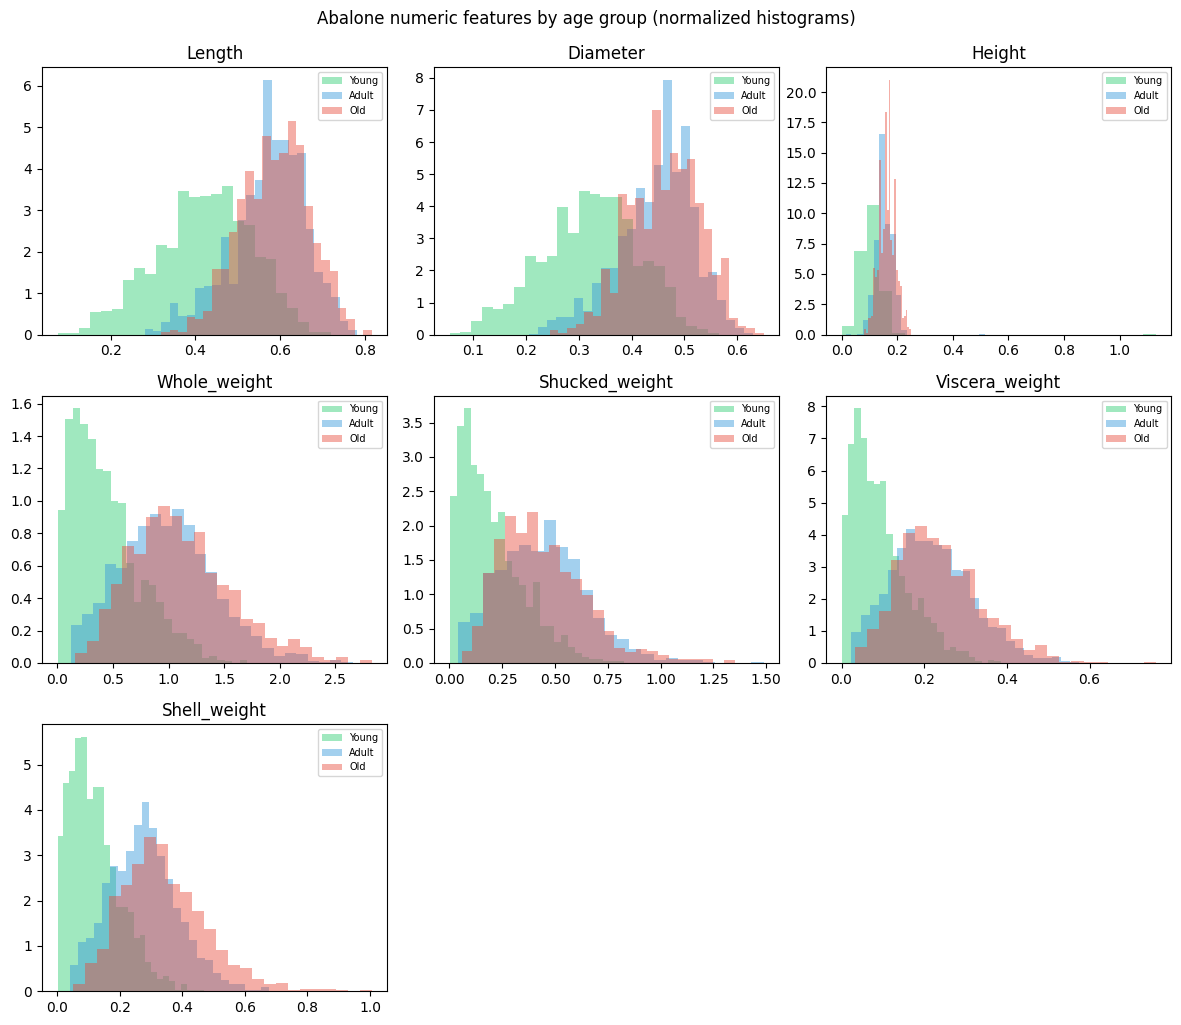

In [ ]:
feature_names = ['Length', 'Diameter', 'Height', 'Whole_weight',
                 'Shucked_weight', 'Viscera_weight', 'Shell_weight']
class_order = ['Young', 'Adult', 'Old']
colors = {'Young': '#2ecc71', 'Adult': '#3498db', 'Old': '#e74c3c'}

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()
for ax, fname in zip(axes[:7], feature_names):
    for c in class_order:
        vals = df_full.loc[df_full['Age_Group'] == c, fname].values
        ax.hist(vals, bins=25, alpha=0.45, label=c, color=colors[c], density=True)
    ax.set_title(fname)
    ax.legend(fontsize=7)
for j in range(7, 9):
    axes[j].axis('off')
plt.tight_layout()
plt.suptitle('Abalone numeric features by age group (normalized histograms)', y=1.02)
plt.show()


### 5.2 – Top 20 Most Frequent Words per Sentiment Class (Multinomial NB)

### 5.3 – Accuracy Comparison Summary